In [11]:
from langchain.tools import tool, ToolRuntime
from langchain_core.messages import HumanMessage, ToolMessage  # 修复消息导入
from langchain.agents import create_agent, AgentState
from langgraph.types import Command
from pydantic import BaseModel  # 修复：BaseModelx → BaseModel

# 内存中 数据格式
class CustomStates(AgentState):
    # 默认继承 messages:list[BaseMessage]
    user_name: str         # 用户名：开发者定制维护的状态

class CustomContext(BaseModel):  # 这里修复！
    user_id: str

# 定义两个工具（状态，上下文 在两个工具之间通过内容传递）
@tool
def update_user_info(runtime: ToolRuntime[CustomContext, CustomStates]) -> Command:
    """查询并更新用户信息"""
    print("========user_info=========")
    user_id = runtime.context.user_id
    name = "帅哥" if user_id == "user_123" else "不知道的用户名"
    return Command(
        update={
            "user_name": name,
            "messages": [
                ToolMessage(
                    content="成功找到用户信息",
                    tool_call_id=runtime.tool_call_id
                )
            ]
        }
    )

@tool
def greet(runtime: ToolRuntime[CustomContext, CustomStates]) -> str | Command:
    """如果查询到用户信息，则使用本工具打招呼"""
    print("========greet=========")
    user_name = runtime.state.get("user_name", None)  # 在内存中找用户名 找不到返回空
    if user_name:
        return f"{user_name} 你好"
    else:
        return Command(
            update={
                "messages": [
                    ToolMessage(
                        content="请调用：update_user_info 来获取/更新用户名",  # 加了content=
                        tool_call_id=runtime.tool_call_id
                    )
                ]
            }
        )

# 创建代理（必须传入 state_schema）
agent = create_agent(
    model="ollama:qwen3.5:9b",
    tools=[update_user_info, greet],
    state_schema=CustomStates  # 必须加！否则自定义状态不生效
)

# 执行
result = agent.invoke(
    {"messages": [HumanMessage(content="hhhh,我是谁？ ")]},
    context=CustomContext(user_id="user_123")
)

# 打印最终结果
print("\n===== 最终对话消息 =====")
for msg in result["messages"]:
    msg.pretty_print()

========user_info=========
========greet=========

===== 最终对话消息 =====
================================ Human Message =================================

hhhh,我是谁？ 
================================== Ai Message ==================================
Tool Calls:
  update_user_info (6c5f7351-1d40-446a-bfa7-b720397b0468)
 Call ID: 6c5f7351-1d40-446a-bfa7-b720397b0468
  Args:
================================= Tool Message =================================
Name: update_user_info

成功找到用户信息
================================== Ai Message ==================================
Tool Calls:
  greet (396ddcc7-d757-492a-bae4-2fe30a8141e2)
 Call ID: 396ddcc7-d757-492a-bae4-2fe30a8141e2
  Args:
================================= Tool Message =================================
Name: greet

帅哥 你好
================================== Ai Message ==================================

你好！我是你的AI助手。有什么我可以帮你的吗？


In [20]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

#=================1. 定义一个模型==================
model = init_chat_model("ollama:gemma4:e4b", temperature=0.3)

#=================2. 定义一个工具===================
@tool
def add(a: int, b: int) -> int:
    """
    将 'a' 和 'b' 相加
    
    参数：
        a: 第一个整型
        b: 第二个整型
    """
    return a + b

@tool
def mutly(a: int, b: int) -> int:
    """
    将 'a' 和 'b' 相乘
    
    参数：
        a: 第一个整型
        b: 第二个整型
    """
    return a * b

@tool
def divide(a: int, b: int) -> float:
    """
    将 'a' 和 'b' 相除
    
    参数：
        a: 第一个整型
        b: 第二个整型
    """
    return a / b

# 工具绑定
tools = [add, mutly, divide]
model_with_tools = model.bind_tools(tools)

# 工具名字映射（必须加！否则找不到工具）
tool_by_name = {tool.name: tool for tool in tools}

#=================3. 定义状态======================
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

#=================4. 定义节点======================
from langchain_core.messages import SystemMessage
from langchain_core.messages import ToolMessage
# 大模型调用节点
system_prompt = "你是一位计算师，负责对一组输入执行算术运算"
def llm_call(state: MessagesState):
    """LLM决定是否调用工具"""
    print(">>>> LLM 调用中")
    outputs = model_with_tools.invoke([SystemMessage(system_prompt)] + state["messages"])

    return {
        "messages": [outputs],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

# 工具调用节点
def tool_node_1(state: MessagesState):
    """执行工具调用"""
    result = []
    print("\t 执行工具...")
    
    # 获取最后一条AI消息
    last_msg = state["messages"][-1]
    
    for tool_call in last_msg.tool_calls:
        tool_name = tool_call["name"]
        tool = tool_by_name[tool_name]
        observation = tool.invoke(tool_call["args"])
        
        # 把工具结果包装成 ToolMessage（必须！）
        from langchain_core.messages import ToolMessage
        result.append(ToolMessage(
            content=str(ToolMessage(observation,tool_call_id = tool_call["id"])),
            tool_call_id=tool_call["id"]
        ))

    return {"messages": result}

def tool_node_2(state: MessagesState):
   pass
def tool_node_3(state: MessagesState):
   pass
def tool_node_4(state: MessagesState):
   pass
#=================5. 定义边 编译===================
from typing_extensions import Literal
from langgraph.graph import StateGraph, START, END

# 条件分支：是否需要调用工具
def branch(state: MessagesState) -> Literal["tool_node_1", END]:
    messages = state["messages"]
    last_message = messages[-1]
    
    # 判断是否有工具调用
    if hasattr(last_message, "tool_calls_1") and last_message.tool_calls_1:
        return "tool_node"
    return END

# 构建图
agent_b = StateGraph(MessagesState)

# 添加节点
agent_b.add_node("llm_call", llm_call)
agent_b.add_node("tool_node_1", tool_node_1)
agent_b.add_node("tool_node_2", tool_node_2)
agent_b.add_node("tool_node_3", tool_node_3)
agent_b.add_node("tool_node_4", tool_node_4)

# 构建流
agent_b.add_edge(START, "llm_call")

agent_b.add_conditional_edges(
    "llm_call",
    branch,  # 分支函数
    {
        "tool_node_1": "tool_node_1",
        END: END
    }
)
agent_b.add_conditional_edges(
    "tool_node_1",
    branch,  # 分支函数
    {
        "tool_node_2": "tool_node_2",
        "tool_node_3": "tool_node_3"
        
    }
)
agent_b.add_conditional_edges(
    "tool_node_3",
    branch,  # 分支函数
    {
        "tool_node_4": "tool_node_4",
        END: END
        
    }
)


agent_b.add_edge("tool_node_2", "tool_node_4")
agent_b.add_edge("tool_node_4", END)



agent_b.add_edge("tool_node_1", "llm_call")  # 工具执行完回到LLM

agent = agent_b.compile()

#=================6. 调用智能体===================
# 修正导入 & 修正调用
from langchain_core.messages import HumanMessage  # 修复导入

# 输入问题
messages = [HumanMessage(content="3 和 4 相加，再乘以5,除以4")]
result = agent.invoke({"messages": messages, "llm_calls": 0})


for m in result["messages"]:  
    m.pretty_print()        

>>>> LLM 调用中
================================ Human Message =================================

3 和 4 相加，再乘以5,除以4
================================== Ai Message ==================================
Tool Calls:
  add (7cfdeeb0-3d18-4a8c-a023-7194aa808a62)
 Call ID: 7cfdeeb0-3d18-4a8c-a023-7194aa808a62
  Args:
    a: 3
    b: 4


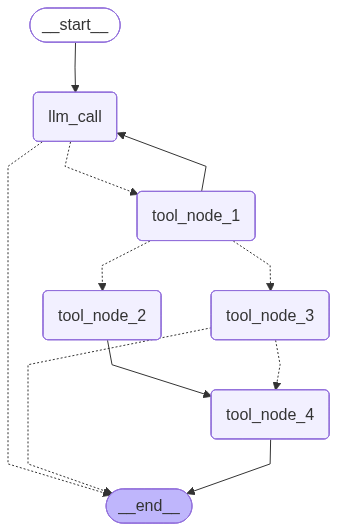

In [21]:
from IPython.display import Image,display
display(Image(agent.get_graph(xray=False).draw_mermaid_png()))

In [24]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

#=================1. 定义一个模型==================
model = init_chat_model("ollama:gemma4:e4b", temperature=0.3)

#=================2. 定义一个工具===================
@tool
def query_time():
    """执行工具调用"""
    return "当前时间是2026年 10月 6日"

@tool
def query_gold_price():
    """金价查询"""
    return 1100

@tool
def public_opinion_analysis():
    """舆情分析"""
    return "国际局势风云变换， 黄金价值水涨船高"

@tool
def investment_decision():
    """决策分析"""
    return "大量购入黄金"

# 工具绑定
tools = [query_time,query_gold_price,public_opinion_analysis,investment_decision]
model_with_tools = model.bind_tools(tools)

# 工具名字映射（必须加！否则找不到工具）
tool_by_name = {tool.name: tool for tool in tools}

#=================3. 定义状态======================
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

#=================4. 定义节点======================
from langchain_core.messages import SystemMessage
from langchain_core.messages import ToolMessage
# 大模型调用节点
system_prompt = "你是一位金融分析师"
def llm_call(state: MessagesState):
    """LLM决定是否调用工具"""
    print(">>>> LLM 调用中")
    outputs = model_with_tools.invoke([SystemMessage(system_prompt)] + state["messages"])

    return {
        "messages": [outputs],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

# 工具调用节点
def tool_node_1(state: MessagesState):
    """执行工具调用"""
    print("\t 查询时间 ...")
    return {"messages": []}

def tool_node_2(state: MessagesState):
   """执行金价查询"""
   print("\t 查询金价 ...")
   return {"messages": []}

def tool_node_3(state: MessagesState):
   """执行舆情分析"""
   print("\t 分析舆情 ...")
   return {"messages": []}

def tool_node_4(state: MessagesState):
   """执行决策投资"""
   print("\t 决策投资 ...")
   return {"messages": []}


#=================5. 定义边 编译===================
from typing_extensions import Literal
from langgraph.graph import StateGraph, START, END

# 条件分支：是否需要调用工具
def branch(state: MessagesState) -> Literal["tool_node_1", END]:
    messages = state["messages"]
    last_message = messages[-1]
    
    # 判断是否有工具调用
    if hasattr(last_message, "tool_calls_1") and last_message.tool_calls_1:
        return "tool_node"
    return END

# 构建图
agent_b = StateGraph(MessagesState)

# 添加节点
agent_b.add_node("llm_call", llm_call)
agent_b.add_node("tool_node_1", tool_node_1)
agent_b.add_node("tool_node_2", tool_node_2)
agent_b.add_node("tool_node_3", tool_node_3)
agent_b.add_node("tool_node_4", tool_node_4)

# 构建流
agent_b.add_edge(START, "llm_call")

agent_b.add_conditional_edges(
    "llm_call",
    branch,  # 分支函数
    {
        "tool_node_1": "tool_node_1",
        END: END
    }
)
agent_b.add_conditional_edges(
    "tool_node_1",
    branch,  # 分支函数
    {
        "tool_node_2": "tool_node_2",
        "tool_node_3": "tool_node_3"
        
    }
)
agent_b.add_conditional_edges(
    "tool_node_3",
    branch,  # 分支函数
    {
        "tool_node_4": "tool_node_4",
        END: END
        
    }
)


agent_b.add_edge("tool_node_2", "tool_node_4")
agent_b.add_edge("tool_node_4", END)



agent_b.add_edge("tool_node_1", "llm_call")  # 工具执行完回到LLM

agent = agent_b.compile()

#=================6. 调用智能体===================
# 修正导入 & 修正调用
from langchain_core.messages import HumanMessage  # 修复导入

# 输入问题
messages = [HumanMessage(content="今天是要买入金价吗？")]
result = agent.invoke({"messages": messages, "llm_calls": 0})


for m in result["messages"]:  
    m.pretty_print()        

>>>> LLM 调用中
================================ Human Message =================================

今天是要买入金价吗？
================================== Ai Message ==================================
Tool Calls:
  investment_decision (2cfd1e7c-e4cd-4986-80ff-93c28d6ad7fc)
 Call ID: 2cfd1e7c-e4cd-4986-80ff-93c28d6ad7fc
  Args:


In [26]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model

#=================1. 定义模型 ==================
model = init_chat_model("ollama:gemma4:e4b", temperature=0.3)

#=================2. 定义工具 ===================
@tool
def query_time():
    """查询当前时间"""
    return "当前时间是2026年 10月 6日"

@tool
def query_gold_price():
    """查询当前金价"""
    return 1100

@tool
def public_opinion_analysis():
    """分析黄金市场舆情"""
    return "国际局势风云变换，黄金价值水涨船高"

@tool
def investment_decision():
    """给出投资决策建议"""
    return "建议：大量购入黄金"

# 工具绑定
tools = [query_time, query_gold_price, public_opinion_analysis, investment_decision]
model_with_tools = model.bind_tools(tools)

# 工具名字映射
tool_by_name = {tool.name: tool for tool in tools}

#=================3. 定义状态 ======================
from typing_extensions import TypedDict, Annotated
from langchain_core.messages import AnyMessage
import operator

class MessagesState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]
    llm_calls: int

#=================4. 定义节点 ======================
from langchain_core.messages import SystemMessage, ToolMessage

# LLM 调用节点
system_prompt = "你是一位专业的金融分析师，会根据工具返回的信息给出准确回答"
def llm_call(state: MessagesState):
    print(">>>> LLM 思考中...")
    outputs = model_with_tools.invoke([SystemMessage(system_prompt)] + state["messages"])
    return {
        "messages": [outputs],
        "llm_calls": state.get("llm_calls", 0) + 1
    }

# ✅ 统一工具执行节点（修复关键！）
def tool_executor(state: MessagesState):
    print(">>>> 开始执行工具...")
    last_msg = state["messages"][-1]
    tool_msgs = []

    # 执行所有工具调用
    for call in last_msg.tool_calls:
        tool = tool_by_name[call["name"]]
        result = tool.invoke(call["args"])
        print(f"✅ 执行工具：{call['name']} | 结果：{result}")
        
        # 把工具结果返回给AI
        tool_msgs.append(ToolMessage(
            content=str(result),
            tool_call_id=call["id"]
        ))

    return {"messages": tool_msgs}

#=================5. 定义流程图 ===================
from typing_extensions import Literal
from langgraph.graph import StateGraph, START, END

# ✅ 正确的分支函数
def should_continue(state: MessagesState) -> Literal["tool_executor", END]:
    last_msg = state["messages"][-1]
    # 判断是否有工具需要执行
    if hasattr(last_msg, "tool_calls") and last_msg.tool_calls:
        return "tool_executor"
    return END

# 构建图
workflow = StateGraph(MessagesState)

# 添加节点
workflow.add_node("llm_call", llm_call)
workflow.add_node("tool_executor", tool_executor)  # 统一工具节点

# 构建流
workflow.add_edge(START, "llm_call")

# 条件分支：工具 or 结束
workflow.add_conditional_edges(
    "llm_call",
    should_continue,
    {"tool_executor": "tool_executor", END: END}
)

# 工具执行完 → 回到LLM
workflow.add_edge("tool_executor", "llm_call")

# 编译
agent = workflow.compile()

#=================6. 调用智能体 ===================
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content="今天适合买入黄金吗？")]
result = agent.invoke({"messages": messages, "llm_calls": 0})

# 打印对话
print("\n" + "="*50)
for m in result["messages"]:
    m.pretty_print()

>>>> LLM 思考中...
>>>> 开始执行工具...
✅ 执行工具：investment_decision | 结果：建议：大量购入黄金
>>>> LLM 思考中...

================================ Human Message =================================

今天适合买入黄金吗？
================================== Ai Message ==================================
Tool Calls:
  investment_decision (f360c018-1f95-4b7b-8e19-bc0fdf839c22)
 Call ID: f360c018-1f95-4b7b-8e19-bc0fdf839c22
  Args:
================================= Tool Message =================================

建议：大量购入黄金
================================== Ai Message ==================================

根据我为您查询的投资决策模型，**目前的建议是：大量购入黄金。**

**【重要提示与分析】**

请注意，我提供的以上信息是基于当前的市场数据和模型分析得出的**参考建议**，它不构成任何具有法律约束力的个人投资建议。金融市场波动性极高，任何投资决策都存在风险。

作为专业的金融分析师，我建议您在做出任何投资决定前，务必考虑以下几点，并结合您个人的财务状况和风险承受能力：

1.  **风险评估：** 黄金通常被视为避险资产，在市场不确定性高或经济动荡时表现较好。但它本身不产生现金流（如股息或利息），其价格波动也受宏观经济、利率政策和地缘政治事件的强烈影响。
2.  **投资组合配置：** 黄金应该作为您投资组合中的**“对冲工具”**，而不是唯一的投资标的。建议您根据您的整体资产配置比例来决定是否增加黄金的权重。
3.  **时间周期：** 投资黄金需要看长远趋势，短期波动的决策应更加谨慎。

**💡 总结建议：**

虽然模型给出了“大量购入”的信号

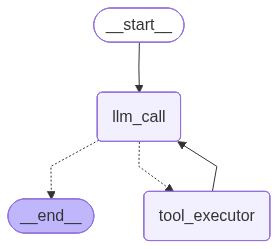

In [27]:
from IPython.display import Image,display
display(Image(agent.get_graph(xray=False).draw_mermaid_png()))